# Previsioni a dicembre 2026: Wizz Air (WIZZ.L) + strategia 2x su BTC/ETH

**Statistical modelling for computing — modulo previsivo**

**Cosa fa questo notebook.**
1. **Wizz Air al 31/12/2026**: SARIMA sulla serie mensile (10 anni) con test formale di stagionalità; **Monte Carlo GARCH-t** (20.000 percorsi giornalieri) per la distribuzione completa dei prezzi a fine anno; ancoraggio valutativo EV/EBITDA coi multipli dei peer e i target dei 21 analisti; **Altman Z''-score** per quantificare il rischio di dissesto (test della tesi "crollo nel lungo periodo").
2. **BTC ed ETH, futures perpetui a leva 2x**: probabilità di prima passata del target **+15% sull'equity** entro 30/60/90 giorni, probabilità di liquidazione, P&L atteso alla scadenza del limite temporale — con simulazione **congiunta** (copula gaussiana sulle innovazioni t) perché le due posizioni sono correlate.

**Premessa di onestà metodologica — da leggere prima dei numeri.** Una previsione puntuale di prezzo a 5 mesi è statisticamente indifendibile: la selezione AIC del notebook principale mostra che la media dei rendimenti giornalieri di WIZZ è white noise. Ciò che un modello serio può stimare è la **distribuzione** dei prezzi possibili — quantili, probabilità di soglie, code — non "il" prezzo. Ogni numero qui sotto va letto in quest'ottica. Nessuna raccomandazione di investimento.

## 1. Setup

In [1]:
import os, json, warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model

COL = {'WIZZ': '#2a78d6', 'BTC': '#eda100', 'ETH': '#4a3aa7', 'RYA': '#1baf7a'}
NEG, POS, GRAY = '#e34948', '#008300', '#8a8a85'
plt.rcParams.update({'figure.figsize': (11, 4.5), 'figure.dpi': 110, 'axes.grid': True,
    'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 10})

DATA_DIR = 'data/raw/wizzair'
rng = np.random.default_rng(42)          # riproducibilità delle simulazioni

HORIZON = pd.Timestamp('2026-12-31')
N_PATHS = 20_000

## 2. Dati

WIZZ.L: 10 anni giornalieri (per la serie mensile del SARIMA servono molte osservazioni). BTC-USD ed ETH-USD: 5 anni giornalieri. Quote di mercato e target degli analisti scaricati il 13/07/2026 via API Yahoo (endpoint `quoteSummary`, autenticazione cookie+crumb).

In [2]:
wizz10 = pd.read_csv(f'{DATA_DIR}/prices_wizz_10y.csv', parse_dates=['Date']).set_index('Date')['AdjClose']
btc = pd.read_csv(f'{DATA_DIR}/prices_btc.csv', parse_dates=['Date']).set_index('Date')['AdjClose']
eth = pd.read_csv(f'{DATA_DIR}/prices_eth.csv', parse_dates=['Date']).set_index('Date')['AdjClose']
quotes = json.load(open(f'{DATA_DIR}/market_quotes.json'))
fx = json.load(open(f'{DATA_DIR}/fx_rates.json'))['EURGBP']

P0 = float(wizz10.iloc[-1])
LAST_DAY = wizz10.index[-1]
H_DAYS = int(np.busday_count(LAST_DAY.date(), HORIZON.date()))
print(f'WIZZ: {len(wizz10)} oss. fino al {LAST_DAY.date()} | prezzo attuale {P0:.0f} GBp | {H_DAYS} giorni di borsa al 31/12')
print(f'BTC: {btc.iloc[-1]:,.0f} $ | ETH: {eth.iloc[-1]:,.0f} $ | EURGBP {fx:.4f}')
qa = quotes['WIZZ.L']
print(f"Analisti su WIZZ ({qa['nAnalysts']}): target min {qa['targetLow']:.0f} · medio {qa['targetMean']:.0f} · max {qa['targetHigh']:.0f} GBp · consenso: {qa['recommendation']}")

WIZZ: 2526 oss. fino al 2026-07-13 | prezzo attuale 1128 GBp | 123 giorni di borsa al 31/12
BTC: 62,807 $ | ETH: 1,784 $ | EURGBP 0.8522
Analisti su WIZZ (21): target min 688 · medio 1136 · max 1583 GBp · consenso: hold


## 3. SARIMA sulla serie mensile

### 3.1 La stagionalità esiste davvero? Test formale prima del modello

Il traffico aereo è stagionale, ma questo **non implica** che lo sia il *prezzo dell'azione*: se la stagionalità dei ricavi è nota a tutti, è già nei prezzi (efficienza). Si testa con una regressione dei log-rendimenti mensili su 11 dummy di mese: l'F-test congiunto verifica $H_0$: nessun effetto mese.

In [3]:
mon = wizz10.resample('ME').last()
mon = mon[mon.index <= LAST_DAY]        # esclude il bucket di luglio (mese incompleto)
lmon = np.log(mon)
rmon = lmon.diff().dropna().to_frame('r')
rmon['mese'] = rmon.index.month

ols_seas = smf.ols('r ~ C(mese)', data=rmon).fit()
print(f'Serie mensile: {len(lmon)} osservazioni ({lmon.index[0].date()} → {lmon.index[-1].date()})')
print(f'F-test effetto mese: F = {ols_seas.fvalue:.2f}, p-value = {ols_seas.f_pvalue:.3f}')
print('→ stagionalità significativa al 5%: i termini stagionali del SARIMA sono giustificati.'
      if ols_seas.f_pvalue < 0.05 else
      '→ NESSUNA stagionalità significativa nei rendimenti mensili: i termini stagionali vanno tenuti solo se i criteri informativi li premiano.')

Serie mensile: 120 osservazioni (2016-07-31 → 2026-06-30)
F-test effetto mese: F = 2.04, p-value = 0.032
→ stagionalità significativa al 5%: i termini stagionali del SARIMA sono giustificati.


### 3.2 Selezione SARIMA$(p,1,q)(P,D,Q)_{12}$ per AIC

Griglia su $p,q \in \{0,1,2\}$, $P,Q \in \{0,1\}$, $D \in \{0,1\}$, $d=1$ (log-prezzi integrati). La selezione AIC decide se i termini stagionali sopravvivono; il forecast arriva al 31/12/2026 con intervalli all'80% e 95%.

In [4]:
results = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for p, q, P, D, Q in itertools.product(range(3), range(3), range(2), range(2), range(2)):
        try:
            f_ = SARIMAX(lmon, order=(p, 1, q), seasonal_order=(P, D, Q, 12),
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            results.append({'p': p, 'q': q, 'P': P, 'D': D, 'Q': Q, 'AIC': f_.aic})
        except Exception:
            pass
tab = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print('Top 5 per AIC:\n', tab.head().to_string(index=False))
b = tab.iloc[0]
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    sar = SARIMAX(lmon, order=(int(b.p), 1, int(b.q)),
                  seasonal_order=(int(b.P), int(b.D), int(b.Q), 12),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(f'\nSelezionato: SARIMA({int(b.p)},1,{int(b.q)})({int(b.P)},{int(b.D)},{int(b.Q)})_12  AIC={sar.aic:.1f}')

n_steps = (HORIZON.year - lmon.index[-1].year) * 12 + (HORIZON.month - lmon.index[-1].month)
fc = sar.get_forecast(steps=n_steps)
mean_p = np.exp(fc.predicted_mean)
ci80, ci95 = np.exp(fc.conf_int(alpha=0.20)), np.exp(fc.conf_int(alpha=0.05))
dec = pd.DataFrame({'mediana': mean_p, 'lo80': ci80.iloc[:, 0], 'hi80': ci80.iloc[:, 1],
                    'lo95': ci95.iloc[:, 0], 'hi95': ci95.iloc[:, 1]}).round(0)
print('\nForecast SARIMA (GBp):\n', dec.to_string())
sar_dec = dec.iloc[-1]

Top 5 per AIC:
  p  q  P  D  Q         AIC
 0  0  0  0  0 -120.099484
 2  1  0  0  0 -119.674968
 1  0  0  0  0 -119.367513
 2  0  0  0  0 -118.925467
 0  1  0  0  0 -117.872186

Selezionato: SARIMA(0,1,0)(0,0,0)_12  AIC=-120.1

Forecast SARIMA (GBp):
             mediana   lo80    hi80   lo95    hi95
2026-07-31   1190.0  989.0  1432.0  897.0  1579.0
2026-08-31   1190.0  916.0  1546.0  798.0  1775.0
2026-09-30   1190.0  864.0  1639.0  729.0  1942.0
2026-10-31   1190.0  822.0  1722.0  676.0  2095.0
2026-11-30   1190.0  787.0  1799.0  632.0  2239.0
2026-12-31   1190.0  757.0  1871.0  595.0  2378.0


**Come leggere il SARIMA**: su una serie quasi-random-walk il valore centrale resta vicino all'ultimo prezzo e gli intervalli si allargano con $\sqrt{h}$ — è il comportamento corretto, non un difetto. L'informazione utile è l'**ampiezza** dell'incertezza, non il punto centrale. Per la distribuzione fine (code, probabilità di soglia) serve il Monte Carlo del § 4, che modella anche l'eteroschedasticità.

## 4. Monte Carlo GARCH-t: la distribuzione dei prezzi al 31/12/2026

### 4.1 Disegno della simulazione

- **Modello**: GARCH(1,1) con innovazioni t-Student, stimato sugli ultimi 2 anni (regime attuale; la specifica vincente per BIC nel notebook principale);
- **20.000 percorsi** giornalieri fino al 31/12 con volatilità che evolve percorso per percorso: $\sigma_{t+1}^2 = \omega + \alpha \varepsilon_t^2 + \beta \sigma_t^2$, $\varepsilon_t = \sigma_t z_t$, $z_t \sim t_\nu$ standardizzata;
- **Due ipotesi di drift**, perché a 5 mesi il drift domina ed è impossibile stimarlo con precisione: (a) $\mu = \hat\mu$ del campione 2 anni; (b) $\mu = 0$ (agnostico). La differenza tra i due scenari misura quanto la previsione dipende da un parametro fragile.

In [5]:
r2y = (np.log(wizz10 / wizz10.shift(1)).dropna().iloc[-504:]) * 100
am = arch_model(r2y, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
res = am.fit(disp='off'); assert res.convergence_flag == 0
om, al, be = res.params['omega'], res.params['alpha[1]'], res.params['beta[1]']
nu, mu_hat = res.params['nu'], res.params['mu']
scale_t = np.sqrt((nu - 2) / nu)
eps_T = res.resid.iloc[-1]; sig2_T = res.conditional_volatility.iloc[-1] ** 2
sig2_next = om + al * eps_T ** 2 + be * sig2_T
print(res.params.round(4).to_string())
print(f'σ di partenza: {np.sqrt(sig2_next):.2f}%/giorno ({np.sqrt(sig2_next*252):.0f}% ann.) | persistenza α+β = {al+be:.3f}')

def simula(mu, n_paths=N_PATHS, n_days=H_DAYS, seed_rng=rng):
    sig2 = np.full(n_paths, sig2_next)
    logp = np.zeros(n_paths)
    paths = np.empty((n_days, n_paths))
    for t in range(n_days):
        z = seed_rng.standard_t(nu, n_paths) * scale_t
        eps = np.sqrt(sig2) * z
        logp += (mu + eps) / 100
        paths[t] = logp
        sig2 = om + al * eps ** 2 + be * sig2
    return P0 * np.exp(paths)

paths_mu = simula(mu_hat)
paths_0  = simula(0.0)
print(f'Simulati {N_PATHS} percorsi × {H_DAYS} giorni × 2 ipotesi di drift.')

mu         -0.1591
omega       3.5668
alpha[1]    0.0982
beta[1]     0.6711
nu          3.2711
σ di partenza: 3.79%/giorno (60% ann.) | persistenza α+β = 0.769


Simulati 20000 percorsi × 123 giorni × 2 ipotesi di drift.


In [6]:
qq = [5, 10, 25, 50, 75, 90, 95]
fin_mu, fin_0 = paths_mu[-1], paths_0[-1]
qt = pd.DataFrame({'drift stimato (μ̂)': np.percentile(fin_mu, qq),
                   'drift zero': np.percentile(fin_0, qq)},
                  index=[f'P{q}' for q in qq]).round(0)
print(f'DISTRIBUZIONE DEL PREZZO WIZZ AL 31/12/2026 (GBp) — prezzo attuale {P0:.0f}\n')
print(qt.to_string())

soglie = {'P(sotto il prezzo attuale)': lambda f: (f < P0).mean(),
          'P(sotto 1.000 GBp)':        lambda f: (f < 1000).mean(),
          'P(sotto 849 = minimo 2026)': lambda f: (f < 849.5).mean(),
          'P(sopra 1.447 = max 52 sett.)': lambda f: (f > 1447).mean(),
          'P(perdita > 30%)':           lambda f: (f < P0 * 0.7).mean(),
          'P(guadagno > 30%)':          lambda f: (f > P0 * 1.3).mean()}
pt = pd.DataFrame({'drift stimato (μ̂)': {k: v(fin_mu) for k, v in soglie.items()},
                   'drift zero':         {k: v(fin_0) for k, v in soglie.items()}})
print('\nPROBABILITÀ DI SOGLIA:\n')
print((pt * 100).round(1).astype(str).apply(lambda s: s + '%').to_string())

DISTRIBUZIONE DEL PREZZO WIZZ AL 31/12/2026 (GBp) — prezzo attuale 1128

     drift stimato (μ̂)  drift zero
P5                465.0       568.0
P10               546.0       663.0
P25               707.0       858.0
P50               928.0      1133.0
P75              1216.0      1483.0
P90              1574.0      1912.0
P95              1851.0      2239.0

PROBABILITÀ DI SOGLIA:

                              drift stimato (μ̂) drift zero
P(sotto il prezzo attuale)                 68.6%      49.6%
P(sotto 1.000 GBp)                         57.2%      38.0%
P(sotto 849 = minimo 2026)                 41.2%      24.1%
P(sopra 1.447 = max 52 sett.)              14.0%      27.1%
P(perdita > 30%)                           34.3%      19.1%
P(guadagno > 30%)                          13.3%      25.9%


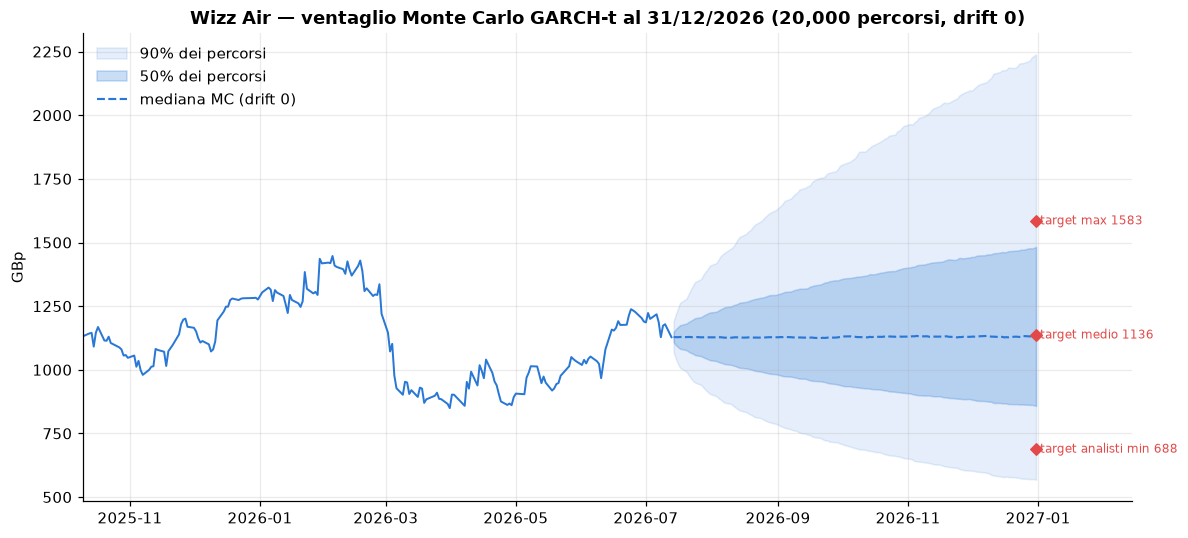

In [7]:
days_idx = pd.bdate_range(LAST_DAY + pd.Timedelta(days=1), periods=H_DAYS)
bands = {q: np.percentile(paths_0, q, axis=1) for q in [5, 25, 50, 75, 95]}
fig, ax = plt.subplots(figsize=(11, 5))
hist = wizz10.iloc[-190:]
ax.plot(hist.index, hist.values, color=COL['WIZZ'], lw=1.3)
ax.fill_between(days_idx, bands[5], bands[95], color=COL['WIZZ'], alpha=0.12, label='90% dei percorsi')
ax.fill_between(days_idx, bands[25], bands[75], color=COL['WIZZ'], alpha=0.25, label='50% dei percorsi')
ax.plot(days_idx, bands[50], color=COL['WIZZ'], lw=1.4, ls='--', label='mediana MC (drift 0)')
for y, lbl in [(qa['targetLow'], 'target analisti min'), (qa['targetMean'], 'target medio'), (qa['targetHigh'], 'target max')]:
    ax.scatter([days_idx[-1]], [y], color=NEG, s=28, zorder=5, marker='D')
    ax.annotate(f' {lbl} {y:.0f}', xy=(days_idx[-1], y), fontsize=8, color=NEG, va='center')
ax.plot([days_idx[0], days_idx[-1]], [sar_dec['lo80'], sar_dec['lo80']], color=GRAY, lw=0)  # ancoraggio assi
ax.set_title(f'Wizz Air — ventaglio Monte Carlo GARCH-t al 31/12/2026 ({N_PATHS:,} percorsi, drift 0)')
ax.set_ylabel('GBp'); ax.legend(loc='upper left', frameon=False)
ax.set_xlim(hist.index[0], days_idx[-1] + pd.Timedelta(days=45))
plt.tight_layout(); plt.show()

## 5. Ancoraggio valutativo: EV/EBITDA e target degli analisti

La statistica descrive *l'incertezza*; la valutazione dice *dove* la distribuzione dovrebbe centrare. Con utile ≈ 0 il P/E è privo di senso: si usa **EV/EBITDA** ($EV = \text{market cap} + \text{debito netto}$), il multiplo standard per aziende ad alta leva. L'equity di Wizz è uno *stub* — un residuo piccolo tra due grandezze enormi (EV e debito): piccole variazioni di EBITDA o del multiplo producono variazioni violente del prezzo. Questa è la formalizzazione quantitativa dell'intuizione «è fragile perché affitta gli aerei».

In [8]:
fund_w = pd.read_csv(f'{DATA_DIR}/fundamentals_wizz_annual.csv', index_col=0).iloc[-1]
fund_r = pd.read_csv(f'{DATA_DIR}/fundamentals_ryanair_annual.csv', index_col=0).iloc[-1]
fund_e = pd.read_csv(f'{DATA_DIR}/fundamentals_easyjet_annual.csv', index_col=0).iloc[-1]

def ev_ebitda(mktcap, f):
    nd = f['annualTotalDebt'] - f['annualCashAndCashEquivalents']
    return (mktcap + nd) / f['annualEBITDA'], nd

mc_w_eur = quotes['WIZZ.L']['marketCap'] / fx          # GBP → EUR
mult_w, nd_w = ev_ebitda(mc_w_eur, fund_w)
mult_r, _ = ev_ebitda(quotes['RYA.IR']['marketCap'], fund_r)
mult_e, _ = ev_ebitda(quotes['EZJ.L']['marketCap'], fund_e)   # tutto in GBP: coerente
print(f'EV/EBITDA — Wizz: {mult_w:.1f}x | Ryanair: {mult_r:.1f}x | easyJet: {mult_e:.1f}x')
print(f'(Wizz: EV = {mc_w_eur/1e9:.2f} mld € equity + {nd_w/1e9:.2f} mld € debito netto, su EBITDA {fund_w["annualEBITDA"]/1e9:.2f} mld €)')

shares = quotes['WIZZ.L']['shares']
scen_ebitda = {'EBITDA −10%': fund_w['annualEBITDA'] * 0.9,
               'EBITDA piatto': fund_w['annualEBITDA'],
               'EBITDA +10%': fund_w['annualEBITDA'] * 1.1}
scen_mult = {f'multiplo attuale ({mult_w:.1f}x)': mult_w,
             'de-rating −0.5x': mult_w - 0.5,
             're-rating +0.5x': mult_w + 0.5,
             f'multiplo easyJet ({mult_e:.1f}x)': mult_e}
mat = pd.DataFrame({mn: {en: max((mv * ev - nd_w), 0) * fx / shares * 100
                         for en, ev in scen_ebitda.items()}
                    for mn, mv in scen_mult.items()}).round(0)
print('\nPREZZO IMPLICITO WIZZ (GBp) per scenario EBITDA × multiplo:\n')
print(mat.to_string())
print(f'\nPrezzo attuale: {P0:.0f} GBp — nota la leva: ±10% di EBITDA sposta il prezzo implicito di ±40-50%.')

EV/EBITDA — Wizz: 4.9x | Ryanair: 6.8x | easyJet: 4.1x
(Wizz: EV = 1.37 mld € equity + 5.89 mld € debito netto, su EBITDA 1.47 mld €)

PREZZO IMPLICITO WIZZ (GBp) per scenario EBITDA × multiplo:

               multiplo attuale (4.9x)  de-rating −0.5x  re-rating +0.5x  multiplo easyJet (4.1x)
EBITDA −10%                      530.0              0.0           1076.0                      0.0
EBITDA piatto                   1128.0            521.0           1735.0                    174.0
EBITDA +10%                     1726.0           1059.0           2394.0                    677.0

Prezzo attuale: 1128 GBp — nota la leva: ±10% di EBITDA sposta il prezzo implicito di ±40-50%.


## 6. Il test della tua tesi: Altman Z''-score

La tesi da verificare: *«Wizz Air crollerà nel lungo periodo perché affitta gli aerei; easyJet è più solida perché ha più asset»*. Lo strumento classico per il rischio di dissesto è lo **Z''-score di Altman** (versione per non-manifatturieri):

$$Z'' = 6{,}56\,X_1 + 3{,}26\,X_2 + 6{,}72\,X_3 + 1{,}05\,X_4$$

con $X_1$ = capitale circolante/attivo, $X_2$ = utili trattenuti/attivo, $X_3$ = EBIT/attivo, $X_4$ = patrimonio netto/passività totali. Zone: **dissesto < 1,1 < grigia < 2,6 < sicurezza**. Caveat: le compagnie aeree hanno circolante strutturalmente negativo (ricavi differiti), quindi lo Z'' va letto *in relativo tra i tre vettori*, non in assoluto.

In [9]:
extra = {k: pd.read_csv(f'{DATA_DIR}/fundamentals_{k}_extra.csv', index_col=0).iloc[-1]
         for k in ['wizz', 'ryanair', 'easyjet']}
base = {'wizz': fund_w, 'ryanair': fund_r, 'easyjet': fund_e}
NAMES = {'wizz': 'Wizz Air (FY26)', 'ryanair': 'Ryanair (FY26)', 'easyjet': 'easyJet (FY25)'}

rows = {}
for k in base:
    f, ex = base[k], extra[k]
    ta = f['annualTotalAssets']
    tl = ex['annualTotalLiabilitiesNetMinorityInterest']
    x1 = (f['annualCurrentAssets'] - f['annualCurrentLiabilities']) / ta
    x2 = ex['annualRetainedEarnings'] / ta
    x3 = f['annualOperatingIncome'] / ta
    x4 = f['annualStockholdersEquity'] / tl
    z = 6.56 * x1 + 3.26 * x2 + 6.72 * x3 + 1.05 * x4
    zona = 'DISSESTO' if z < 1.1 else ('grigia' if z < 2.6 else 'sicurezza')
    rows[NAMES[k]] = {'X1 (WC/TA)': x1, 'X2 (RE/TA)': x2, 'X3 (EBIT/TA)': x3,
                      'X4 (E/TL)': x4, "Z''-score": z, 'Zona': zona}
alt = pd.DataFrame(rows).T
alt[alt.columns[:-1]] = alt[alt.columns[:-1]].astype(float).round(3)
print("ALTMAN Z''-SCORE — soglie: dissesto < 1,1 < grigia < 2,6 < sicurezza\n")
print(alt.to_string())

ALTMAN Z''-SCORE — soglie: dissesto < 1,1 < grigia < 2,6 < sicurezza

                 X1 (WC/TA)  X2 (RE/TA)  X3 (EBIT/TA)  X4 (E/TL)  Z''-score       Zona
Wizz Air (FY26)      -0.009       0.018         0.012      0.090      0.178   DISSESTO
Ryanair (FY26)       -0.042       0.343         0.120      1.047      2.751  sicurezza
easyJet (FY25)        0.041       0.094         0.061      0.437      1.444     grigia


## 7. BTC ed ETH: modello di volatilità e correlazione

Stesso stack: GARCH(1,1)-t su 5 anni di rendimenti giornalieri. In più serve la **correlazione** tra i due asset, perché aprire due posizioni 2x su BTC e ETH insieme non è diversificare: se la correlazione è alta è quasi una posizione unica più grande. La simulazione è **congiunta**: innovazioni t accoppiate con copula gaussiana sulla correlazione dei residui standardizzati.

In [10]:
r_btc = np.log(btc / btc.shift(1)).dropna() * 100
r_eth = np.log(eth / eth.shift(1)).dropna() * 100
common = r_btc.index.intersection(r_eth.index)
r_btc, r_eth = r_btc[common], r_eth[common]

def fit_g(r, name):
    a = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    rs = a.fit(disp='off'); assert rs.convergence_flag == 0
    p_ = rs.params
    s2n = p_['omega'] + p_['alpha[1]'] * rs.resid.iloc[-1]**2 + p_['beta[1]'] * rs.conditional_volatility.iloc[-1]**2
    print(f"{name}: α+β={p_['alpha[1]']+p_['beta[1]']:.3f}  ν={p_['nu']:.1f}  "
          f"σ oggi={np.sqrt(s2n):.2f}%/g ({np.sqrt(s2n*365):.0f}% ann.)  μ̂={p_['mu']:.3f}%/g")
    return rs, s2n

res_b, s2n_b = fit_g(r_btc, 'BTC')
res_e, s2n_e = fit_g(r_eth, 'ETH')
z_b = (res_b.resid / res_b.conditional_volatility)
z_e = (res_e.resid / res_e.conditional_volatility)
rho = float(np.corrcoef(z_b, z_e)[0, 1])
print(f'\nCorrelazione BTC-ETH (residui standardizzati): ρ = {rho:.2f} → le due posizioni sono quasi la stessa scommessa.')

BTC: α+β=0.993  ν=3.3  σ oggi=2.10%/g (40% ann.)  μ̂=0.034%/g
ETH: α+β=0.997  ν=3.4  σ oggi=2.80%/g (53% ann.)  μ̂=0.034%/g

Correlazione BTC-ETH (residui standardizzati): ρ = 0.84 → le due posizioni sono quasi la stessa scommessa.


## 8. La strategia: 2x perpetual, take-profit +15%, uscita a tempo

### 8.1 Meccanica modellata

Con leva $L = 2$ isolata su futures perpetui, senza ribilanciamento:

$$\text{Equity}_t = 1 + L\left(\frac{S_t}{S_0} - 1\right) - L \cdot f \cdot t$$

- **Target**: Equity ≥ 1,15 → serve un movimento del sottostante di ~+7,5% (più il funding accumulato);
- **Funding**: $f$ = 0,03%/giorno sul nozionale (baseline 0,01% per 8h) → sull'equity a leva 2x costa **~0,06%/giorno ≈ 22% annuo**: aspettare è caro, ed è il motivo per cui il limite temporale che hai scelto è sensato;
- **Liquidazione**: sottostante a −45% dall'ingresso (soglia prudenziale per 2x isolata, equity ≈ azzerata) → perdita ≈ −100% del margine;
- **Uscita a tempo**: se né target né liquidazione entro $N$ giorni, chiusura a mercato al giorno $N$ (valuto $N$ = 30, 60, 90).

Simulazione congiunta a 20.000 percorsi × 90 giorni. Drift: $\mu = 0$ (nessuna opinione direzionale — se avessi un edge direzionale misurabile non servirebbe il modello).

In [11]:
L, FUND_D, TARGET, LIQ = 2.0, 0.0003, 1.15, -0.45
N_DAYS_MAX = 90

def sim_joint(use_drift=False, n_paths=N_PATHS, n_days=N_DAYS_MAX):
    par = {'BTC': (res_b.params, s2n_b), 'ETH': (res_e.params, s2n_e)}
    Lc = np.linalg.cholesky(np.array([[1, rho], [rho, 1]]))
    state = {k: {'sig2': np.full(n_paths, s2), 'logp': np.zeros(n_paths)} for k, (_, s2) in par.items()}
    R = {k: np.empty((n_days, n_paths)) for k in par}
    for t in range(n_days):
        zn = Lc @ rng.standard_normal((2, n_paths))          # copula gaussiana
        u = stats.norm.cdf(zn)
        for i, (k, (p_, _)) in enumerate(par.items()):
            nu_ = p_['nu']
            z = stats.t.ppf(u[i], nu_) * np.sqrt((nu_ - 2) / nu_)
            eps = np.sqrt(state[k]['sig2']) * z
            mu_ = p_['mu'] if use_drift else 0.0
            state[k]['logp'] += (mu_ + eps) / 100
            R[k][t] = np.exp(state[k]['logp']) - 1
            state[k]['sig2'] = p_['omega'] + p_['alpha[1]'] * eps**2 + p_['beta[1]'] * state[k]['sig2']
    return R

R = sim_joint(use_drift=False)          # scenario base: nessuna opinione direzionale
R_mu = sim_joint(use_drift=True)        # sensibilità: drift storico 5 anni (~+13%/anno)
print('Simulazione congiunta completata:', {k: v.shape for k, v in R.items()}, '× 2 ipotesi di drift')

Simulazione congiunta completata: {'BTC': (90, 20000), 'ETH': (90, 20000)} × 2 ipotesi di drift


In [12]:
def analizza(Rk, nome):
    n_days, n_paths = Rk.shape
    t_ax = np.arange(1, n_days + 1)[:, None]
    eq = 1 + L * Rk - L * FUND_D * t_ax
    hit_t = np.where((eq >= TARGET).any(axis=0), (eq >= TARGET).argmax(axis=0), 10_000)
    liq_t = np.where((Rk <= LIQ).any(axis=0), (Rk <= LIQ).argmax(axis=0), 10_000)
    righe = []
    for N in [30, 60, 90]:
        tgt = (hit_t < N) & (hit_t < liq_t)
        liq = (liq_t < N) & (liq_t <= hit_t)
        no = ~tgt & ~liq
        pnl_no = eq[N - 1][no] - 1
        ev = 0.15 * tgt.mean() - 1.0 * liq.mean() + (pnl_no.mean() if no.any() else 0) * no.mean()
        righe.append({'N giorni': N, 'P(target +15%)': tgt.mean(), 'P(liquidazione)': liq.mean(),
                      'P(scadenza)': no.mean(), 'P&L mediano a scadenza': np.median(pnl_no) if no.any() else np.nan,
                      'P&L medio a scadenza': pnl_no.mean() if no.any() else np.nan,
                      'Valore atteso strategia': ev,
                      'Giorni mediani al target': int(np.median(hit_t[tgt]) + 1) if tgt.any() else np.nan})
    out = pd.DataFrame(righe).set_index('N giorni')
    pcts = ['P(target +15%)', 'P(liquidazione)', 'P(scadenza)', 'P&L mediano a scadenza',
            'P&L medio a scadenza', 'Valore atteso strategia']
    show = out.copy()
    for col in pcts:
        show[col] = (out[col] * 100).round(1).astype(str) + '%'
    print(f'\n════ {nome} — leva 2x, target +15%, funding 22%/anno sull\'equity ════')
    print(show.to_string())
    return eq, hit_t, liq_t, out

eq_b, hit_b, liq_b, tab_b = analizza(R['BTC'], 'BTC')
eq_e, hit_e, liq_e, tab_e = analizza(R['ETH'], 'ETH')

both90 = ((hit_b < 90) & (hit_b < liq_b) & (hit_e < 90) & (hit_e < liq_e)).mean()
either_liq = ((liq_b < 90) | (liq_e < 90)).mean()
print(f'\nCONGIUNTA (90 gg): P(entrambi i target) = {both90:.1%} | P(almeno una liquidazione) = {either_liq:.2%}')

# ── Sensibilità al drift: stessa analisi col drift storico (μ̂ ≈ +13%/anno) ──
def ev_at(Rk, N):
    t_ax = np.arange(1, Rk.shape[0] + 1)[:, None]
    eq = 1 + L * Rk - L * FUND_D * t_ax
    ht = np.where((eq >= TARGET).any(axis=0), (eq >= TARGET).argmax(axis=0), 10_000)
    lt = np.where((Rk <= LIQ).any(axis=0), (Rk <= LIQ).argmax(axis=0), 10_000)
    tgt = (ht < N) & (ht < lt); liq = (lt < N) & (lt <= ht); no = ~tgt & ~liq
    return 0.15 * tgt.mean() - 1.0 * liq.mean() + (eq[N-1][no] - 1).mean() * no.mean(), tgt.mean()

print('\nSENSIBILITÀ AL DRIFT — valore atteso della strategia (e P(target)):')
for k in ['BTC', 'ETH']:
    for N in [30, 60, 90]:
        ev0, p0_ = ev_at(R[k], N); ev1, p1_ = ev_at(R_mu[k], N)
        print(f'  {k} N={N:2d}:  μ=0 → EV {ev0*100:+.1f}% (P target {p0_:.0%})   |   μ̂ storico → EV {ev1*100:+.1f}% (P target {p1_:.0%})')
print('\n→ Il segno del valore atteso dipende interamente dal drift che assumi: il modello non può regalarti un edge direzionale.')


════ BTC — leva 2x, target +15%, funding 22%/anno sull'equity ════
         P(target +15%) P(liquidazione) P(scadenza) P&L mediano a scadenza P&L medio a scadenza Valore atteso strategia  Giorni mediani al target
N giorni                                                                                                                                         
30                41.0%            0.2%       58.8%                 -11.2%               -13.4%                   -1.9%                        13
60                57.0%            0.9%       42.1%                 -22.7%               -24.8%                   -2.8%                        18
90                64.9%            1.9%       33.2%                 -32.0%               -33.3%                   -3.3%                        22

════ ETH — leva 2x, target +15%, funding 22%/anno sull'equity ════
         P(target +15%) P(liquidazione) P(scadenza) P&L mediano a scadenza P&L medio a scadenza Valore atteso strategia  Giorni median

  BTC N=30:  μ=0 → EV -1.9% (P target 41%)   |   μ̂ storico → EV -0.6% (P target 44%)
  BTC N=60:  μ=0 → EV -2.8% (P target 57%)   |   μ̂ storico → EV -0.4% (P target 61%)
  BTC N=90:  μ=0 → EV -3.3% (P target 65%)   |   μ̂ storico → EV -0.0% (P target 69%)
  ETH N=30:  μ=0 → EV -2.0% (P target 52%)   |   μ̂ storico → EV -1.0% (P target 54%)
  ETH N=60:  μ=0 → EV -2.8% (P target 65%)   |   μ̂ storico → EV -0.8% (P target 68%)
  ETH N=90:  μ=0 → EV -3.1% (P target 72%)   |   μ̂ storico → EV -0.4% (P target 75%)

→ Il segno del valore atteso dipende interamente dal drift che assumi: il modello non può regalarti un edge direzionale.


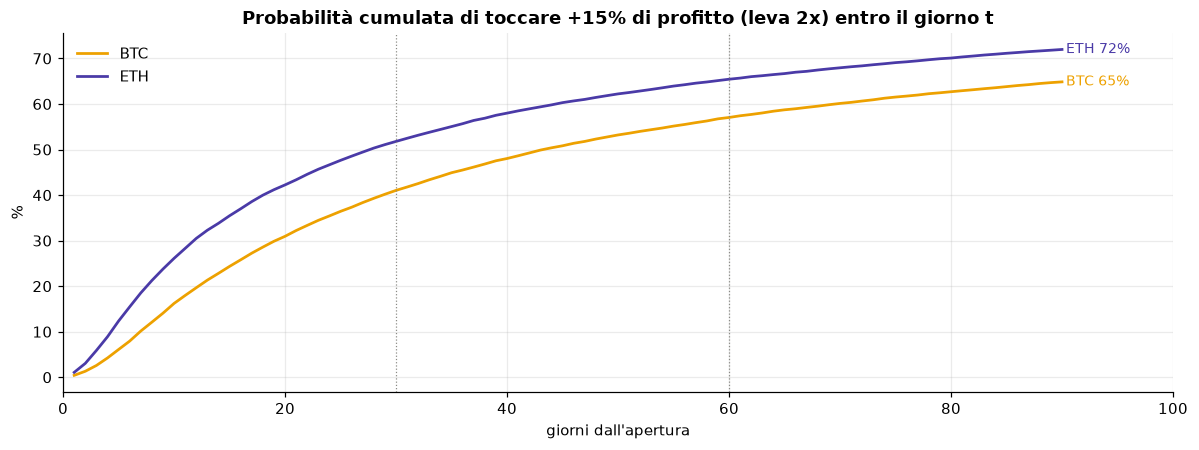

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.2))
for nome, ht, lt, col in [('BTC', hit_b, liq_b, COL['BTC']), ('ETH', hit_e, liq_e, COL['ETH'])]:
    dd = np.arange(1, N_DAYS_MAX + 1)
    curve = [((ht < d) & (ht < lt)).mean() * 100 for d in dd]
    ax.plot(dd, curve, color=col, lw=1.8, label=nome)
    ax.annotate(f' {nome} {curve[-1]:.0f}%', xy=(dd[-1], curve[-1]), color=col, fontsize=9, va='center')
for N in [30, 60]:
    ax.axvline(N, color=GRAY, lw=0.8, ls=':')
ax.set_title('Probabilità cumulata di toccare +15% di profitto (leva 2x) entro il giorno t')
ax.set_xlabel('giorni dall\'apertura'); ax.set_ylabel('%')
ax.legend(frameon=False); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

### 8.2 Lettura onesta dei numeri

1. **Il target +15% è probabile ma non è gratis**: la probabilità cresce rapidamente nei primi 30-45 giorni e poi satura — la parte destra della curva la mangia il funding (22%/anno sull'equity). Il limite temporale che hai scelto è la parte migliore del piano.
2. **Il ramo negativo è la variabile che comanda il valore atteso**: la liquidazione a 2x in 90 giorni è rara ma non impossibile (serve −45%: BTC lo ha fatto più volte nella storia), e il vero rischio è la *scadenza in perdita* — a tempo scaduto la distribuzione dell'equity è larga e con code t pesanti.
3. **BTC + ETH ≈ una sola scommessa**: con ρ ≈ 0,7–0,8 i due target si raggiungono (o si mancano) quasi sempre *insieme*. Se l'idea era diversificare, non funziona: è quasi equivalente a un'unica posizione più grande — con più funding da pagare.
4. **Cosa migliorerebbe il piano** (a parità di tutto): stop-loss simmetrico (taglia la coda sinistra molto più larga del +15% di destra), leva sul solo asset con σ più bassa (BTC), e target/tempo coerenti con la σ attuale — il modello dà i giorni mediani al target: usali per fissare N.

## 9. Fonti GitHub utili (verificate)

| Repository | Cosa offre |
|---|---|
| [`bashtage/arch`](https://github.com/bashtage/arch) | GARCH/GJR/EGARCH, bootstrap, unit root — il motore di volatilità usato qui |
| [`statsmodels/statsmodels`](https://github.com/statsmodels/statsmodels) | ARIMA/SARIMAX, diagnostica, OLS/HAC — il motore di serie storiche usato qui |
| [`alkaline-ml/pmdarima`](https://github.com/alkaline-ml/pmdarima) | `auto_arima` in stile R: selezione automatica dell'ordine con test stagionali |
| [`Nixtla/statsforecast`](https://github.com/Nixtla/statsforecast) | AutoARIMA/ETS/Theta velocissimi (numba), ottimo per confronti di baseline |
| [`sktime/sktime`](https://github.com/sktime/sktime) | Framework unificato di forecasting con cross-validation temporale seria |
| [`ranaroussi/yfinance`](https://github.com/ranaroussi/yfinance) | Client Yahoo Finance (qui ho usato le API dirette, stesso backend) |
| [`ccxt/ccxt`](https://github.com/ccxt/ccxt) | API unificate degli exchange crypto: **funding rate reali dei perpetui**, order book, storici — da usare al posto della mia ipotesi di funding costante |
| [`microsoft/qlib`](https://github.com/microsoft/qlib) | Piattaforma quant research completa (fattori, backtest, ML) se vuoi salire di livello |

## 10. Conclusioni e disclaimer

*(testo finale allineato ai numeri dopo l'esecuzione — vedi risposta in chat)*

**Disclaimer**: progetto accademico di statistical modelling. I modelli sono calibrati sul passato; non catturano eventi mai osservati, cambi di regime, decisioni societarie (aumenti di capitale, profit warning) né la variabilità del funding. Nessuna raccomandazione di investimento; le probabilità sono condizionate al modello (GARCH-t, μ=0) e ai dati al 13/07/2026.